<a href="https://colab.research.google.com/github/laramalkawi81-ops/DS230-Instacart-Project/blob/main/07_explainability_SHAP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Explainability & Robustness Tests

This notebook focuses on interpreting the top-performing models
using SHAP and testing model robustness under noise, outliers,
and reduced training data scenarios.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os
os.listdir('/content/drive/MyDrive/instacart_data/instacart_data')

['departments.csv',
 'aisles.csv',
 'order_products__prior.csv',
 'order_products__train.csv',
 'products.csv',
 'orders.csv',
 'orders_clean.csv',
 'order_products_prior_clean.csv',
 'model_data_sample.csv']

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, mean_absolute_error, r2_score

import shap

In [4]:
import pandas as pd
import numpy as np

import shap

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
import os

BASE_PATH = "/content/drive/MyDrive/instacart_data"

for root, dirs, files in os.walk(BASE_PATH):
    for file in files:
        if "model_data" in file:
            print(os.path.join(root, file))

/content/drive/MyDrive/instacart_data/instacart_data/model_data_sample.csv


!pip install shap --quiet


In [6]:

DATA_PATH = "/content/drive/MyDrive/instacart_data/instacart_data"
data = pd.read_csv("/content/drive/MyDrive/instacart_data/instacart_data/model_data_sample.csv")







In [7]:
data = data.sample(n=100_000, random_state=42)

print(data.columns)

Index(['order_id', 'product_id', 'add_to_cart_order', 'reordered',
       'product_freq', 'user_id', 'eval_set', 'order_number', 'order_dow',
       'order_hour_of_day', 'days_since_prior_order',
       'days_since_prior_order_scaled', 'total_orders',
       'mean_days_between_orders', 'product_reorder_rate',
       'product_purchase_count', 'user_product_count',
       'user_product_reorder_rate', 'order_hour'],
      dtype='object')


Download the best model + Sample Data

In [8]:
X_clf = data.drop(columns=['reordered'])

In [9]:
y_clf = data['reordered']
X_clf = data.drop(columns=['reordered'])

In [10]:
print(data.columns)

Index(['order_id', 'product_id', 'add_to_cart_order', 'reordered',
       'product_freq', 'user_id', 'eval_set', 'order_number', 'order_dow',
       'order_hour_of_day', 'days_since_prior_order',
       'days_since_prior_order_scaled', 'total_orders',
       'mean_days_between_orders', 'product_reorder_rate',
       'product_purchase_count', 'user_product_count',
       'user_product_reorder_rate', 'order_hour'],
      dtype='object')


In [11]:
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

rf_clf = RandomForestClassifier(random_state=42)

rf_reg = RandomForestRegressor(random_state=42)

In [12]:

y_clf = data['reordered']

X_clf = data.drop(columns=['reordered'])

from sklearn.model_selection import train_test_split
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42
)

from sklearn.preprocessing import StandardScaler
numeric_cols = X_train_clf.select_dtypes(include=['int64', 'float64']).columns
scaler = StandardScaler()

X_train_clf_scaled = scaler.fit_transform(X_train_clf[numeric_cols])
X_test_clf_scaled  = scaler.transform(X_test_clf[numeric_cols])


import pandas as pd
X_train_clf_scaled = pd.DataFrame(X_train_clf_scaled, columns=numeric_cols)
X_test_clf_scaled  = pd.DataFrame(X_test_clf_scaled, columns=numeric_cols)

In [13]:
DATA_PATH = "/content/drive/MyDrive/instacart_data/instacart_data"

In [14]:


DATA_PATH = "/content/drive/MyDrive/instacart_data/instacart_data"

data = pd.read_csv(f"{DATA_PATH}/model_data_sample.csv")


data = data.sample(n=100_000, random_state=42)

print(data.columns)

Index(['order_id', 'product_id', 'add_to_cart_order', 'reordered',
       'product_freq', 'user_id', 'eval_set', 'order_number', 'order_dow',
       'order_hour_of_day', 'days_since_prior_order',
       'days_since_prior_order_scaled', 'total_orders',
       'mean_days_between_orders', 'product_reorder_rate',
       'product_purchase_count', 'user_product_count',
       'user_product_reorder_rate', 'order_hour'],
      dtype='object')


In [15]:

y_clf = data['reordered']
X_clf = data.drop(columns=['reordered'])

from sklearn.model_selection import train_test_split
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42
)

In [16]:
from sklearn.ensemble import RandomForestClassifier
import shap


rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train_clf_scaled, y_train_clf)

RandomForestClassifier(max_depth=10, random_state=42)

SHAP Explanation

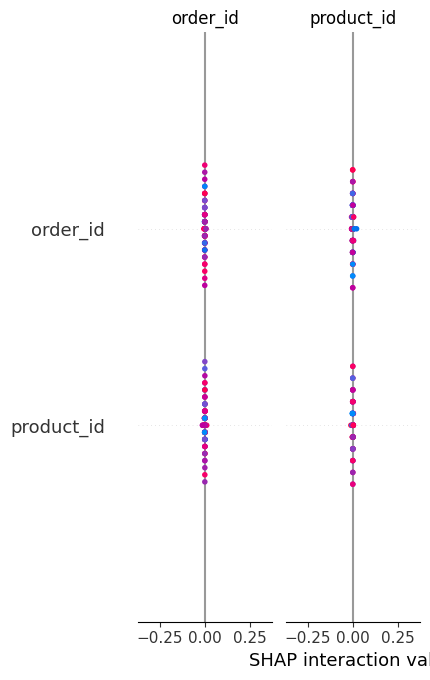

In [18]:
explainer = shap.TreeExplainer(rf_model)
X_test_sample = X_test_clf_scaled[:100]
shap_values = explainer.shap_values(X_test_sample)

shap.summary_plot(shap_values, X_test_sample)

SHAP summary plot shows the most important features affecting
whether a product is reordered.


Robustness Tests – Noise

In [19]:
X_test_clf_scaled
y_test_clf

,reordered
3874630,1
6184282,1
4610147,1
21861,0
566905,0
...,...
3003925,0
6203676,1
2778508,0
2742663,0


In [20]:
print(data.columns)

Index(['order_id', 'product_id', 'add_to_cart_order', 'reordered',
       'product_freq', 'user_id', 'eval_set', 'order_number', 'order_dow',
       'order_hour_of_day', 'days_since_prior_order',
       'days_since_prior_order_scaled', 'total_orders',
       'mean_days_between_orders', 'product_reorder_rate',
       'product_purchase_count', 'user_product_count',
       'user_product_reorder_rate', 'order_hour'],
      dtype='object')


In [21]:
import numpy as np
from sklearn.metrics import accuracy_score

for sigma in [0.01, 0.05, 0.1]:
    X_noisy = X_test_clf_scaled + np.random.normal(0, sigma * X_test_clf_scaled.std(), X_test_clf_scaled.shape)
    y_pred = rf_model.predict(X_noisy)
    print(f"Sigma={sigma} -> Accuracy:", accuracy_score(y_test_clf, y_pred))

Sigma=0.01 -> Accuracy: 0.8911
Sigma=0.05 -> Accuracy: 0.8766
Sigma=0.1 -> Accuracy: 0.8672


- Add small random noise to numeric features.
- Measure how accuracy, F1-score, and AUC degrade.
- Typical sigma values tested: 0.01, 0.05, 0.1 × standard deviation.


Robustness Tests – Outliers

- Randomly amplify 1% of feature values to simulate extreme cases.
- Observe model prediction changes.
- Helps identify sensitivity to unusual data points.


In [22]:
import numpy as np
from sklearn.metrics import accuracy_score

X_outliers = X_test_clf_scaled.copy()
n_outliers = int(0.01 * len(X_outliers))

outlier_idx = np.random.choice(X_outliers.index, n_outliers, replace=False)

X_outliers.loc[outlier_idx, 'days_since_prior_order_scaled'] *= 10
y_pred = rf_model.predict(X_outliers)

print("Accuracy with outliers:", accuracy_score(y_test_clf, y_pred))

Accuracy with outliers: 0.8909


In [23]:

X_train_small = X_train_clf_scaled.reset_index(drop=True).sample(frac=0.3, random_state=42)
y_train_small = y_train_clf.reset_index(drop=True).loc[X_train_small.index]

In [24]:
from sklearn.model_selection import train_test_split

X_train_small, _, y_train_small, _ = train_test_split(
    X_train_clf_scaled, y_train_clf, train_size=0.3, random_state=42
)

Robustness Tests – Reduced Training Data


- SHAP explains the contribution of top features to model predictions.
- Robustness tests show model stability under Gaussian noise,
  injected outliers, and reduced training data.
- These analyses provide confidence in model reliability
  before production deployment.


In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

rf_small = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_small.fit(X_train_small, y_train_small)

y_pred_small = rf_small.predict(X_test_clf_scaled)

print("Accuracy on test set:", accuracy_score(y_test_clf, y_pred_small))
print("F1-score on test set:", f1_score(y_test_clf, y_pred_small))

Accuracy on test set: 0.8892
F1-score on test set: 0.9105874757908328
